Jumlah data yang dibaca dari Excel: 320
Total data: 320
Jumlah data training: 288
Jumlah data testing: 32

Akurasi data training sebelum K-fold: 82.99%
Akurasi data testing sebelum K-fold: 75.00%

Hasil Validasi Silang (10 Fold):
Fold 1:
  Indeks data training: [  0   2   3   4   5   6   7   9  10  11  12  13  14  15  16  17  18  19
  20  21  23  24  25  26  27  28  29  30  31  33  34  35  36  37  38  39
  40  42  43  44  45  47  48  49  50  51  52  53  54  55  56  57  58  59
  60  61  62  63  64  65  66  67  68  70  71  73  74  75  76  77  78  79
  80  81  82  83  84  85  87  89  90  91  92  93  94  95  96  97  98 100
 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 137 138
 139 140 141 143 144 145 146 147 148 149 152 153 154 155 156 157 158 159
 160 162 163 164 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 183 184 185 186 187 188 190 191 192 193 194 195 196 197 198 199
 200 201

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Hasil prediksi untuk citra dengan fitur yang dimasukkan: Retina Normal


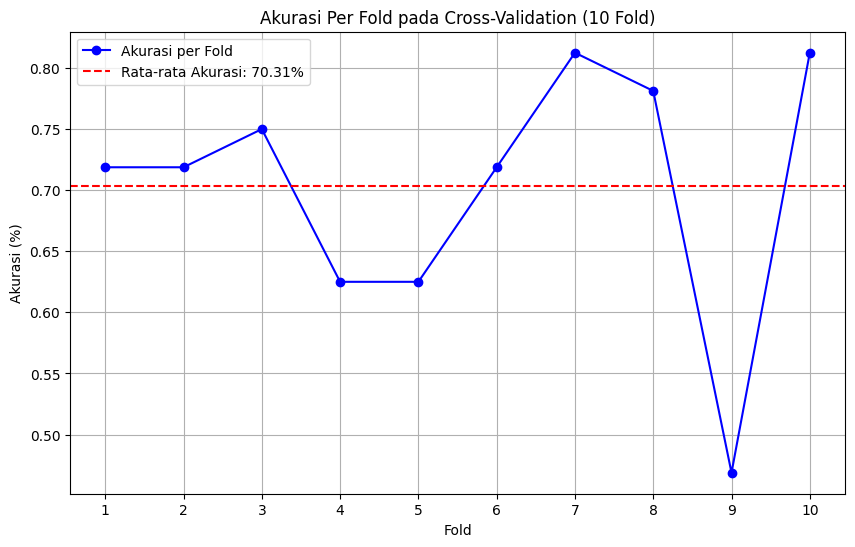

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Set randomness globally
np.random.seed(42)

# 1. Load dataset
file_path = "Klasifikasi Katarak(1).xlsx"  # Ganti dengan path file Anda
data = pd.read_excel(file_path)

# Cek jumlah data yang dibaca
print(f"Jumlah data yang dibaca dari Excel: {data.shape[0]}")  # Harus 320

# 2. Praproses data
data.columns = ['Feature1', 'Feature2', 'Feature3', 'Label']  # Ganti sesuai kolom Anda
label_encoder = LabelEncoder()
data['EncodedLabel'] = label_encoder.fit_transform(data['Label'])

X = data[['Feature1', 'Feature2', 'Feature3']]
y = data['EncodedLabel']

# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduksi Dimensi menggunakan PCA (jika perlu)
pca = PCA(n_components=3, random_state=42)  # Tetapkan random_state
X_pca = pca.fit_transform(X_scaled)


# 3. Split data untuk training dan testing
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X_pca, y, np.arange(len(y)), test_size=0.1, random_state=42
)

# Menampilkan jumlah data
print(f"Total data: {len(y)}")  # Harus 320
print(f"Jumlah data training: {len(X_train)}")  # Harus 288
print(f"Jumlah data testing: {len(X_test)}")    # Harus 32

# 4. Model SVM dengan hyperparameter terbaik
svm_model = SVC(C=1000, gamma=1, kernel='rbf', probability=True, decision_function_shape='ovr', random_state=42)

# Evaluasi awal pada data training dan testing
y_train_pred_initial = svm_model.fit(X_train, y_train).predict(X_train)
y_test_pred_initial = svm_model.predict(X_test)

train_accuracy_initial = accuracy_score(y_train, y_train_pred_initial)
test_accuracy_initial = accuracy_score(y_test, y_test_pred_initial)

print(f"\nAkurasi data training sebelum K-fold: {train_accuracy_initial * 100:.2f}%")
print(f"Akurasi data testing sebelum K-fold: {test_accuracy_initial * 100:.2f}%")

# 8. Cross-validation dengan 10 fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\nHasil Validasi Silang (10 Fold):")
cv_scores = []
best_accuracy = 0
best_model = None
best_fold = None
best_train_indices = None
best_test_indices = None

for fold, (train_idx, test_idx) in enumerate(cv.split(X_pca, y), start=1):
    X_train_fold, X_test_fold = X_pca[train_idx], X_pca[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # Melatih model pada fold ini
    svm_model.fit(X_train_fold, y_train_fold)
    y_pred_fold = svm_model.predict(X_test_fold)
    accuracy = accuracy_score(y_test_fold, y_pred_fold)
    cv_scores.append(accuracy)

    # Laporan klasifikasi dan matriks kebingungan
    class_report = classification_report(y_test_fold, y_pred_fold, target_names=label_encoder.classes_)
    conf_matrix_fold = confusion_matrix(y_test_fold, y_pred_fold)

    # Menampilkan hasil fold
    print(f"Fold {fold}:")
    print(f"  Indeks data training: {train_idx}")
    print(f"  Indeks data testing: {test_idx}")
    print(f"  Akurasi: {accuracy * 100:.2f}%")
    print(f"\nLaporan Klasifikasi (Fold {fold}):")
    print(class_report)
    print(f"\nMatriks Kebingungan (Fold {fold}):")
    print(conf_matrix_fold)

    # Simpan model dan akurasi terbaik
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = svm_model  # Simpan model pada fold ini
        best_fold = fold  # Simpan nomor fold terbaik
        best_train_indices = train_idx  # Simpan indeks training terbaik
        best_test_indices = test_idx  # Simpan indeks testing terbaik

# Rata-rata akurasi dari K-fold
mean_cv_accuracy = np.mean(cv_scores)
print(f"\nRata-rata akurasi dari K-fold: {mean_cv_accuracy * 100:.2f}%")
print(f"Akurasi tertinggi dari K-fold (Fold {best_fold}): {best_accuracy * 100:.2f}%")

# Menampilkan data Fold terbaik
print("\nIndeks data yang digunakan untuk training pada Fold dengan akurasi terbaik:")
print(best_train_indices)

print("\nIndeks data yang digunakan untuk testing pada Fold dengan akurasi terbaik:")
print(best_test_indices)

# Evaluasi model pada data testing menggunakan model terbaik
y_test_pred_final = best_model.predict(X_test)
test_accuracy_final = accuracy_score(y_test, y_test_pred_final)

# Menghitung akurasi pada data training untuk model terbaik
y_train_pred_final = best_model.predict(X_train)
train_accuracy_final = accuracy_score(y_train, y_train_pred_final)

print(f"\nAkurasi data training (model terbaik): {train_accuracy_final * 100:.2f}%")
print(f"Akurasi data testing (model terbaik): {test_accuracy_final * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi (Testing):")
print(classification_report(y_test, y_test_pred_final, target_names=label_encoder.classes_))

# Matriks kebingungan untuk data testing
conf_matrix_test = confusion_matrix(y_test, y_test_pred_final)
print("\nMatriks Kebingungan (Testing):")
print(conf_matrix_test)


# Menghitung sensitivitas dan spesifisitas untuk setiap kelas
num_classes = conf_matrix_test.shape[0]
sensitivity = []
specificity = []

for i in range(num_classes):
    TN = conf_matrix_test.sum() - conf_matrix_test[i, :].sum() - conf_matrix_test[:, i].sum() + conf_matrix_test[i, i]
    FP = conf_matrix_test[:, i].sum() - conf_matrix_test[i, i]
    FN = conf_matrix_test[i, :].sum() - conf_matrix_test[i, i]
    TP = conf_matrix_test[i, i]

    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

# Menampilkan sensitivitas dan spesifisitas untuk setiap kelas
print("\nSensitivitas dan Spesifisitas untuk setiap kelas:")
for i in range(num_classes):
    print(f"Kelas {label_encoder.classes_[i]}:")
    print(f"  Sensitivitas (Recall): {sensitivity[i] * 100:.2f}%")
    print(f"  Spesifisitas: {specificity[i] * 100:.2f}%")

def predict_user_input():
    try:
        print("\nMasukkan nilai fitur citra untuk prediksi:")
        feature1 = float(input("Feature1: "))  # Input dari pengguna untuk Feature1
        feature2 = float(input("Feature2: "))  # Input dari pengguna untuk Feature2
        feature3 = float(input("Feature3: "))  # Input dari pengguna untuk Feature3
    except ValueError:
        print("Input tidak valid. Pastikan memasukkan angka.")
        return

    # Standarisasi input pengguna
    user_input = np.array([[feature1, feature2, feature3]])  # Membentuk array dengan input pengguna
    user_input_scaled = scaler.transform(user_input)  # Standarisasi input pengguna

    # Reduksi dimensi input menggunakan PCA
    user_input_pca = pca.transform(user_input_scaled)

    # Prediksi dengan model SVM dari Fold terbaik
    prediction = best_model.predict(user_input_pca)

    # Tampilkan hasil prediksi
    predicted_class = label_encoder.inverse_transform(prediction)
    print(f"\nHasil prediksi untuk citra dengan fitur yang dimasukkan: {predicted_class[0]}")

# Menjalankan fungsi prediksi berdasarkan input pengguna
predict_user_input()

# 9. Plot grafik akurasi tiap fold
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linestyle='-', color='b', label='Akurasi per Fold')
plt.axhline(y=mean_cv_accuracy, color='r', linestyle='--', label=f'Rata-rata Akurasi: {mean_cv_accuracy * 100:.2f}%')
plt.title('Akurasi Per Fold pada Cross-Validation (10 Fold)')
plt.xlabel('Fold')
plt.ylabel('Akurasi (%)')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend()
plt.grid(True)
plt.show()